In [5]:
pip install --upgrade typing_extensions
pip install --upgrade pydantic mlflow

SyntaxError: invalid syntax (901923065.py, line 1)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_iris
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)
import xgboost as xgb
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch

print(' All libraries imported!')

 All libraries imported!


In [7]:
# ── 1.1  Load Data ────────────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
bc      = load_breast_cancer(as_frame=True)

# Regression split
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42)

# Classification split
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=42, stratify=bc.target)

print('Housing dataset:', housing.data.shape)
print('Breast cancer  :', bc.data.shape)

Housing dataset: (20640, 8)
Breast cancer  : (569, 30)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Scaling
scaler_h = StandardScaler()
Xh_tr_sc = scaler_h.fit_transform(Xh_tr)
Xh_te_sc = scaler_h.transform(Xh_te)

# Store results
results = {}

# Models
models = [
    ('Linear', LinearRegression()),
    ('Ridge α=0.1', Ridge(alpha=0.1)),
    ('Ridge α=10', Ridge(alpha=10)),
    ('Lasso α=0.01', Lasso(alpha=0.01))
]

# Training loop
for name, model in models:
    model.fit(Xh_tr_sc, yh_tr)
    pred = model.predict(Xh_te_sc)
    
    # FIXED RMSE
    rmse = np.sqrt(mean_squared_error(yh_te, pred))
    r2 = r2_score(yh_te, pred)
    
    results[name] = {
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    }

# Display results
df_results = pd.DataFrame(results).T
print(df_results)

                RMSE      R²
Linear        0.7456  0.5758
Ridge α=0.1   0.7456  0.5758
Ridge α=10    0.7453  0.5761
Lasso α=0.01  0.7404  0.5816


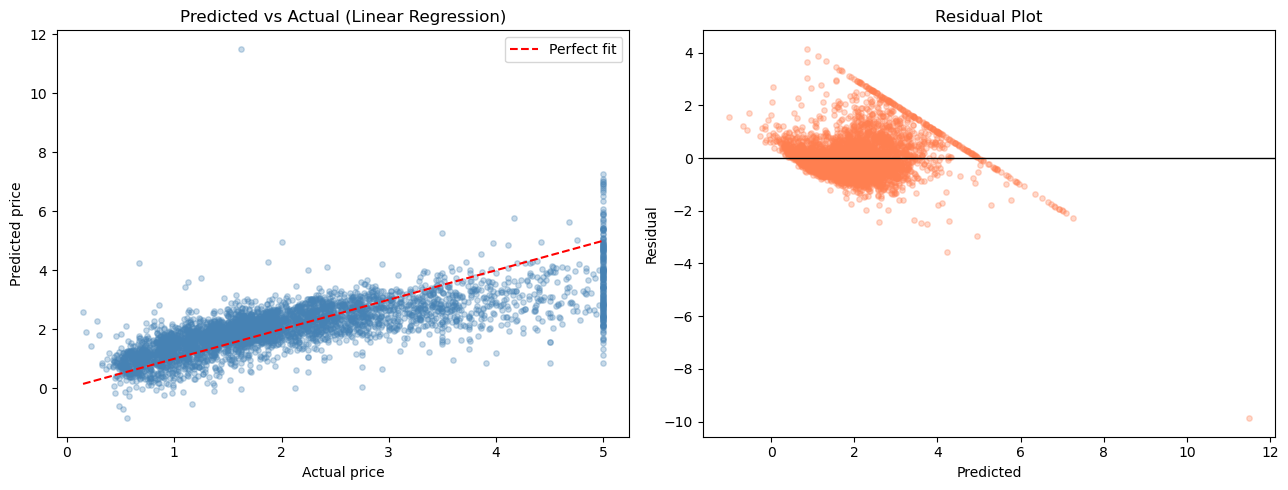

In [9]:
# ── 1.3  Prediction vs Actual + Residuals ─────────────────────────────────────
lr_model = LinearRegression().fit(Xh_tr_sc, yh_tr)
preds    = lr_model.predict(Xh_te_sc)
residuals = yh_te.values - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yh_te, preds, alpha=0.3, s=15, color='steelblue')
mn, mx = yh_te.min(), yh_te.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual price'); axes[0].set_ylabel('Predicted price')
axes[0].set_title('Predicted vs Actual (Linear Regression)')
axes[0].legend()

axes[1].scatter(preds, residuals, alpha=0.3, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout(); plt.show()

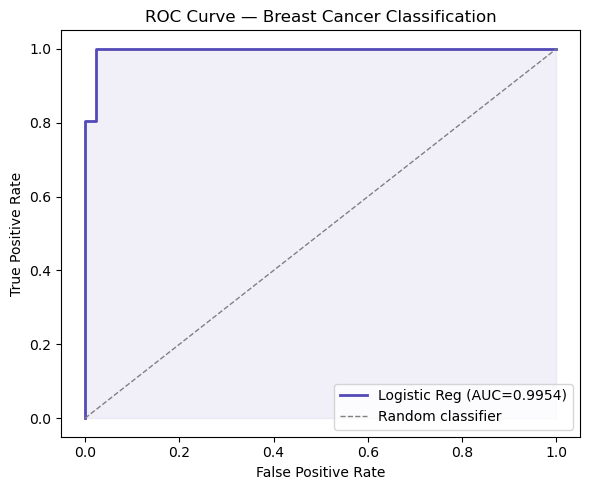

Accuracy : 0.9825
ROC-AUC  : 0.9954


In [11]:
# ── 1.4  Logistic Regression + ROC Curve ─────────────────────────────────────
scaler_b = StandardScaler()
Xb_tr_sc = scaler_b.fit_transform(Xb_tr)
Xb_te_sc = scaler_b.transform(Xb_te)

log_reg = LogisticRegression(max_iter=1000, C=1.0)
log_reg.fit(Xb_tr_sc, yb_tr)
proba = log_reg.predict_proba(Xb_te_sc)[:, 1]

fpr, tpr, thresholds = roc_curve(yb_te, proba)
auc = roc_auc_score(yb_te, proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#534AB7', linewidth=2, label=f'Logistic Reg (AUC={auc:.4f})')
ax.plot([0,1],[0,1],'--',color='gray',linewidth=1,label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#534AB7')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Breast Cancer Classification')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print(f'Accuracy : {accuracy_score(yb_te, log_reg.predict(Xb_te_sc)):.4f}')
print(f'ROC-AUC  : {auc:.4f}')

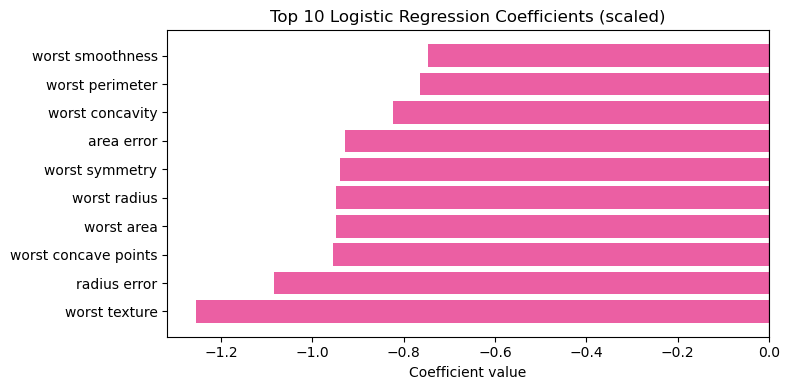

In [12]:
# ── 1.5  Coefficient Interpretation ─────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': bc.feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E84393' if c < 0 else '#1D9E75' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Logistic Regression Coefficients (scaled)')
ax.set_xlabel('Coefficient value')
plt.tight_layout(); plt.show()

In [13]:
# ── 2.1  5-Fold Stratified CV ────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000), bc.data, bc.target,
    cv=skf, scoring='roc_auc'
)
print('CV ROC-AUC scores:', cv_scores.round(4))
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV ROC-AUC scores: [0.9934 0.9889 0.9851 0.997  0.999 ]
Mean: 0.9927 ± 0.0051


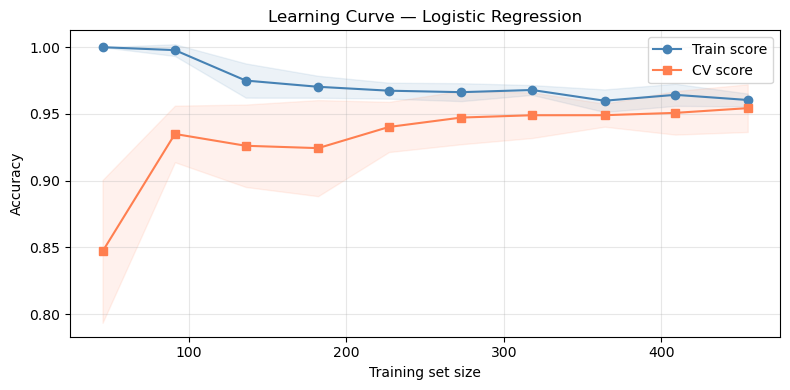

In [14]:
# ── 2.2  Learning Curve — Diagnosing Bias vs Variance ────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), bc.data, bc.target,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

tr_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Train score')
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.1, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='coral', label='CV score')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='coral')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Logistic Regression')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [15]:
# ── 3.1  Decision Tree Baseline ───────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, export_text

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(Xb_tr, yb_tr)

print('Decision Tree (depth=4):')
print(f'  Train acc : {dt.score(Xb_tr, yb_tr):.4f}')
print(f'  Test  acc : {dt.score(Xb_te, yb_te):.4f}')
print()

# Visualise top 3 levels of the tree
print(export_text(dt, feature_names=list(bc.feature_names), max_depth=2))

Decision Tree (depth=4):
  Train acc : 0.9868
  Test  acc : 0.9386

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- truncated branch of depth 2
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- truncated branch of depth 2
|   |   |--- worst texture >  25.62
|   |   |   |--- truncated branch of depth 2
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- truncated branch of depth 2
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



In [16]:
# ── 3.2  Random Forest with GridSearchCV ──────────────────────────────────────
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)
rf_cv.fit(Xb_tr, yb_tr)

rf_best = rf_cv.best_estimator_
print(f'Best params : {rf_cv.best_params_}')
print(f'CV AUC      : {rf_cv.best_score_:.4f}')
print(f'Test AUC    : {roc_auc_score(yb_te, rf_best.predict_proba(Xb_te)[:,1]):.4f}')
print(f'Test acc    : {rf_best.score(Xb_te, yb_te):.4f}')

Best params : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
CV AUC      : 0.9889
Test AUC    : 0.9927
Test acc    : 0.9561


In [17]:
# ── 3.3  XGBoost Classifier ───────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', use_label_encoder=False, random_state=42
)
xgb_model.fit(
    Xb_tr, yb_tr,
    eval_set=[(Xb_te, yb_te)],
    verbose=False
)

xgb_auc = roc_auc_score(yb_te, xgb_model.predict_proba(Xb_te)[:,1])
print(f'XGBoost test acc : {xgb_model.score(Xb_te, yb_te):.4f}')
print(f'XGBoost test AUC : {xgb_auc:.4f}')

XGBoost test acc : 0.9561
XGBoost test AUC : 0.9947


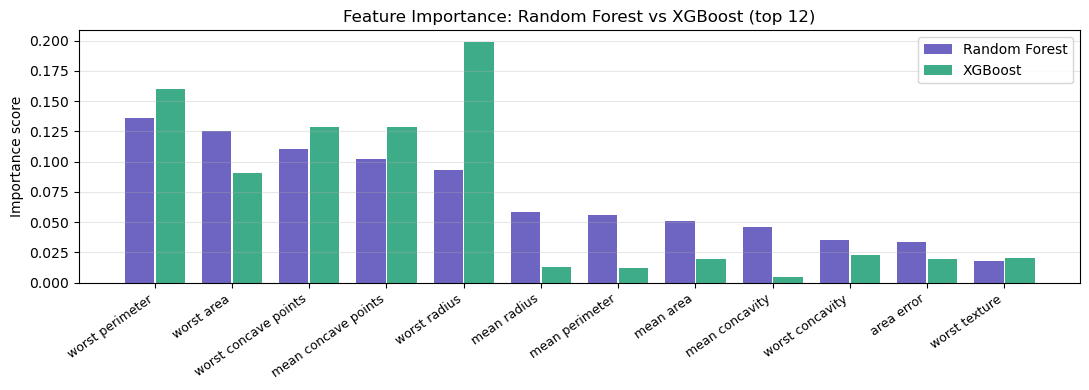

In [18]:
# ── 3.4  Feature Importance Comparison ───────────────────────────────────────
rf_imp  = rf_best.feature_importances_
xgb_imp = xgb_model.feature_importances_

top_n = 12
top_idx = np.argsort(rf_imp)[::-1][:top_n]
feat_names = np.array(bc.feature_names)[top_idx]

x = np.arange(top_n)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, rf_imp[top_idx],  0.38, label='Random Forest', color='#534AB7', alpha=0.85)
ax.bar(x + 0.2, xgb_imp[top_idx], 0.38, label='XGBoost',       color='#1D9E75', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feat_names, rotation=35, ha='right', fontsize=9)
ax.set_title('Feature Importance: Random Forest vs XGBoost (top 12)')
ax.set_ylabel('Importance score')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

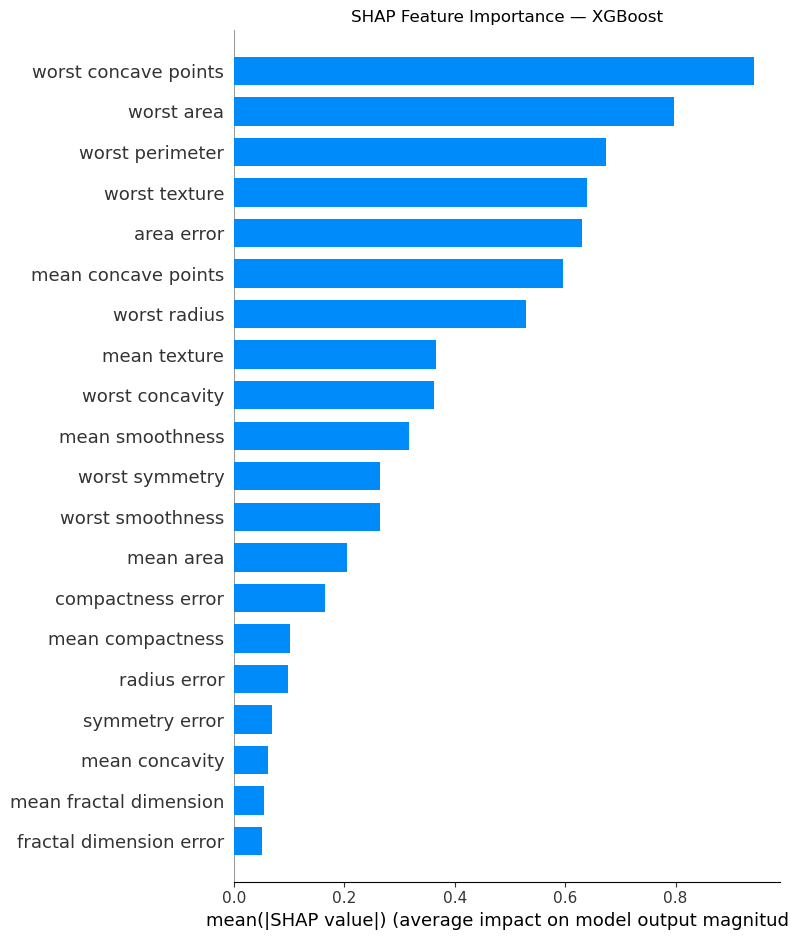

✅ SHAP plot complete


In [19]:
# ── 3.5  SHAP Values (XGBoost) ───────────────────────────────────────────────
try:
    import shap
    explainer  = shap.TreeExplainer(xgb_model)
    shap_vals  = explainer.shap_values(Xb_te)

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_vals, Xb_te, feature_names=list(bc.feature_names),
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — XGBoost')
    plt.tight_layout(); plt.show()
    print('✅ SHAP plot complete')
except ImportError:
    print('Install shap: pip install shap')
    print('Skipping SHAP — feature importance bar chart above is equivalent for now.')

In [20]:
# ── 3.6  Model Comparison Summary ────────────────────────────────────────────
models = {
    'Decision Tree': dt,
    'Random Forest': rf_best,
    'XGBoost': xgb_model,
    'Logistic Reg': log_reg
}
comparison = []
for name, m in models.items():
    if name == 'Logistic Reg':
        y_pr = m.predict(Xb_te_sc)
        prb  = m.predict_proba(Xb_te_sc)[:,1]
    else:
        y_pr = m.predict(Xb_te)
        prb  = m.predict_proba(Xb_te)[:,1]
    comparison.append({
        'Model': name,
        'Accuracy': round(accuracy_score(yb_te, y_pr), 4),
        'ROC-AUC': round(roc_auc_score(yb_te, prb), 4)
    })

comp_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
print(comp_df.to_string(index=False))

        Model  Accuracy  ROC-AUC
 Logistic Reg    0.9825   0.9954
      XGBoost    0.9561   0.9947
Random Forest    0.9561   0.9927
Decision Tree    0.9386   0.9342


In [21]:
# ── 5.1  Prepare PyTorch Tensors ──────────────────────────────────────────────
scaler_nn = StandardScaler()
Xb_tr_nn  = scaler_nn.fit_transform(Xb_tr)
Xb_te_nn  = scaler_nn.transform(Xb_te)

X_tr_t = torch.tensor(Xb_tr_nn, dtype=torch.float32)
X_te_t = torch.tensor(Xb_te_nn, dtype=torch.float32)
y_tr_t = torch.tensor(yb_tr.values, dtype=torch.float32)
y_te_t = torch.tensor(yb_te.values, dtype=torch.float32)

print(f'Train tensors : X={X_tr_t.shape}, y={y_tr_t.shape}')
print(f'Test  tensors : X={X_te_t.shape}, y={y_te_t.shape}')
print(f'Device        : {"GPU" if torch.cuda.is_available() else "CPU"}')

Train tensors : X=torch.Size([455, 30]), y=torch.Size([455])
Test  tensors : X=torch.Size([114, 30]), y=torch.Size([114])
Device        : CPU


In [22]:
# ── 5.2  Define Multi-Layer Perceptron ────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze()

model = MLP(input_dim=30, hidden_dims=[64, 32], dropout=0.3)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters: 4,289


In [23]:
# ── 5.3  Training & Evaluation Functions ──────────────────────────────────────
def train_epoch(model, X, y, optimizer, loss_fn):
    model.train()
    optimizer.zero_grad()
    preds = model(X)
    loss  = loss_fn(preds, y)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    proba = model(X).numpy()
    preds = (proba >= 0.5).astype(int)
    acc   = accuracy_score(y.numpy(), preds)
    auc   = roc_auc_score(y.numpy(), proba)
    return acc, auc

print('✅ Training functions defined')

✅ Training functions defined


In [24]:
# ── 5.4  Training Loop with MLflow Tracking ───────────────────────────────────
EPOCHS    = 80
LR        = 1e-3
HIDDEN    = [64, 32]
DROPOUT   = 0.3

train_losses, test_accs, test_aucs = [], [], []

mlflow.set_experiment('breast_cancer_mlp')

with mlflow.start_run(run_name='MLP_64_32_dropout'):
    mlflow.log_params({
        'lr': LR, 'epochs': EPOCHS,
        'hidden_dims': str(HIDDEN), 'dropout': DROPOUT
    })

    model    = MLP(30, HIDDEN, DROPOUT)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    loss_fn  = nn.BCELoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, X_tr_t, y_tr_t, optimizer, loss_fn)
        scheduler.step()
        acc, auc = evaluate(model, X_te_t, y_te_t)

        train_losses.append(loss)
        test_accs.append(acc)
        test_aucs.append(auc)

        mlflow.log_metrics({'train_loss': loss, 'test_acc': acc, 'test_auc': auc}, step=epoch)

        if epoch % 20 == 0:
            print(f'Epoch {epoch:>3} | Loss: {loss:.4f} | Acc: {acc:.4f} | AUC: {auc:.4f}')

    mlflow.log_metric('final_test_acc', test_accs[-1])
    mlflow.log_metric('final_test_auc', test_aucs[-1])
    mlflow.pytorch.log_model(model, 'mlp_model')
    print(f'\n✅ Run logged to MLflow!')
    print(f'   Final Acc : {test_accs[-1]:.4f}')
    print(f'   Final AUC : {test_aucs[-1]:.4f}')

2026/03/23 14:03:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/23 14:03:44 INFO mlflow.store.db.utils: Updating database tables
2026/03/23 14:03:45 INFO mlflow.tracking.fluent: Experiment with name 'breast_cancer_mlp' does not exist. Creating a new experiment.


Epoch  20 | Loss: 0.4008 | Acc: 0.9211 | AUC: 0.9848
Epoch  40 | Loss: 0.3199 | Acc: 0.9386 | AUC: 0.9921
Epoch  60 | Loss: 0.2781 | Acc: 0.9386 | AUC: 0.9937


2026/03/23 14:03:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 14:03:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch  80 | Loss: 0.2671 | Acc: 0.9386 | AUC: 0.9944

✅ Run logged to MLflow!
   Final Acc : 0.9386
   Final AUC : 0.9944


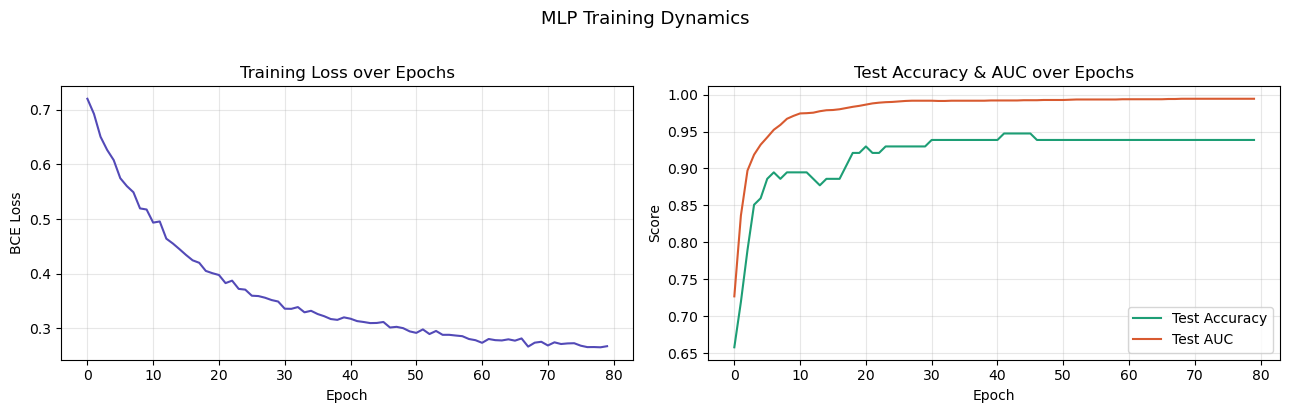

In [25]:
# ── 5.5  Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, color='#534AB7', linewidth=1.5)
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(test_accs, label='Test Accuracy', color='#1D9E75')
axes[1].plot(test_aucs, label='Test AUC',      color='#D85A30')
axes[1].set_title('Test Accuracy & AUC over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('MLP Training Dynamics', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [26]:
# ── 5.6  Compare Multiple Architectures via MLflow ────────────────────────────
architectures = [
    {'hidden': [32],      'lr': 1e-3, 'epochs': 60},
    {'hidden': [64, 32],  'lr': 1e-3, 'epochs': 60},
    {'hidden': [128, 64, 32], 'lr': 5e-4, 'epochs': 60},
]

arch_results = []
with mlflow.start_run(run_name='architecture_sweep', nested=False):
    for cfg in architectures:
        m   = MLP(30, cfg['hidden'], dropout=0.2)
        opt = torch.optim.Adam(m.parameters(), lr=cfg['lr'])
        lfn = nn.BCELoss()
        for _ in range(cfg['epochs']):
            train_epoch(m, X_tr_t, y_tr_t, opt, lfn)
        acc, auc = evaluate(m, X_te_t, y_te_t)
        arch_results.append({'Architecture': str(cfg['hidden']), 'Acc': round(acc,4), 'AUC': round(auc,4)})
        print(f"  {str(cfg['hidden']):20s} → Acc={acc:.4f}  AUC={auc:.4f}")

print('\n', pd.DataFrame(arch_results).to_string(index=False))

  [32]                 → Acc=0.9386  AUC=0.9917
  [64, 32]             → Acc=0.9649  AUC=0.9964
  [128, 64, 32]        → Acc=0.9561  AUC=0.9940

  Architecture    Acc    AUC
         [32] 0.9386 0.9917
     [64, 32] 0.9649 0.9964
[128, 64, 32] 0.9561 0.9940


In [27]:
# ── 5.7  Save & Reload PyTorch Model ─────────────────────────────────────────
torch.save(model.state_dict(), 'mlp_breast_cancer.pt')
print('✅ Model saved to mlp_breast_cancer.pt')

# Reload
model_reload = MLP(30, [64, 32], dropout=0.3)
model_reload.load_state_dict(torch.load('mlp_breast_cancer.pt'))
model_reload.eval()

acc_r, auc_r = evaluate(model_reload, X_te_t, y_te_t)
print(f'Reloaded model — Acc: {acc_r:.4f} | AUC: {auc_r:.4f} ✓')

✅ Model saved to mlp_breast_cancer.pt
Reloaded model — Acc: 0.9386 | AUC: 0.9944 ✓


=== FINAL LEADERBOARD ===
              Model  Accuracy  ROC-AUC
Logistic Regression    0.9825   0.9954
            XGBoost    0.9561   0.9947
      MLP (PyTorch)    0.9386   0.9944
      Random Forest    0.9561   0.9927
      Decision Tree    0.9386   0.9342


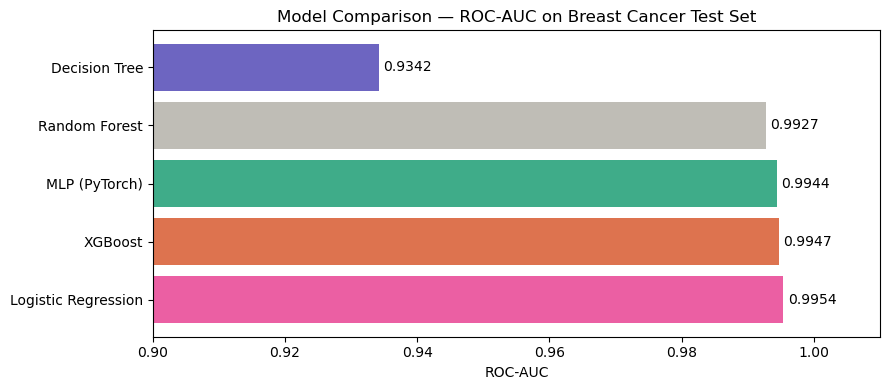

In [28]:
# ── 5.8  Grand Final Model Comparison ────────────────────────────────────────
acc_mlp, auc_mlp = evaluate(model, X_te_t, y_te_t)

final = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(yb_te, log_reg.predict(Xb_te_sc)),
     'ROC-AUC': roc_auc_score(yb_te, log_reg.predict_proba(Xb_te_sc)[:,1])},
    {'Model': 'Decision Tree',       'Accuracy': dt.score(Xb_te, yb_te),
     'ROC-AUC': roc_auc_score(yb_te, dt.predict_proba(Xb_te)[:,1])},
    {'Model': 'Random Forest',       'Accuracy': rf_best.score(Xb_te, yb_te),
     'ROC-AUC': roc_auc_score(yb_te, rf_best.predict_proba(Xb_te)[:,1])},
    {'Model': 'XGBoost',             'Accuracy': xgb_model.score(Xb_te, yb_te),
     'ROC-AUC': roc_auc_score(yb_te, xgb_model.predict_proba(Xb_te)[:,1])},
    {'Model': 'MLP (PyTorch)',        'Accuracy': acc_mlp, 'ROC-AUC': auc_mlp},
]).sort_values('ROC-AUC', ascending=False).round(4)

print('=== FINAL LEADERBOARD ===')
print(final.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#534AB7','#B4B2A9','#1D9E75','#D85A30','#E84393']
bars = ax.barh(final['Model'], final['ROC-AUC'], color=colors[::-1], alpha=0.85)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_xlim(0.9, 1.01)
ax.set_title('Model Comparison — ROC-AUC on Breast Cancer Test Set')
ax.set_xlabel('ROC-AUC')
plt.tight_layout(); plt.show()